C:\Users\tomer\AppData\Local\Temp\ipykernel_26364\3718142597.py:17: DtypeWarning: Columns (0: snr_db, 1: source_id) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv('../../data/metadata.csv')


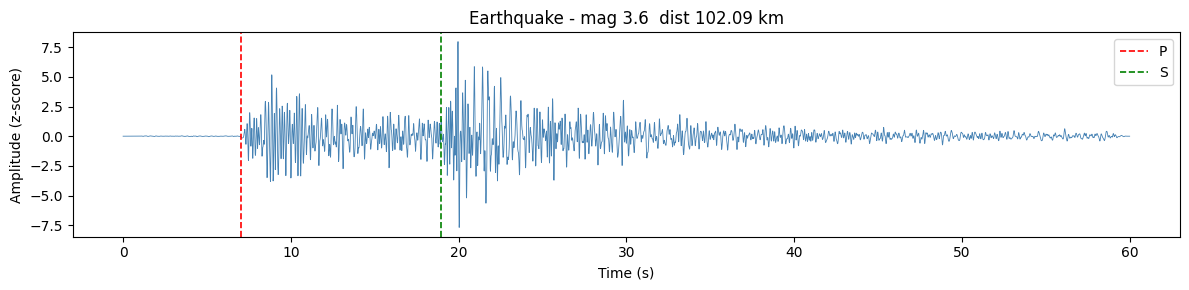

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
except NameError:
    pass

# Make src importable from the project root
sys.path.insert(0, os.path.abspath('../..'))

X    = np.load('../../data/waveforms.npy')
meta = pd.read_csv('../../data/metadata.csv')

# Global spectrogram color scale — same dB value = same colour in every plot
with open('../../data/statistics.json') as f:
    _stats = json.load(f)
VMIN = _stats['spectrogram_db_range']['p2']
VMAX = _stats['spectrogram_db_range']['p98']

idx      = np.where(meta['label'].values == 1)[0][0]
waveform = X[idx]
row      = meta.iloc[idx]

time = np.arange(len(waveform)) / 100.0

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(time, waveform, lw=0.6, color='steelblue')
for col, label, color in [('p_arrival_sample', 'P', 'red'), ('s_arrival_sample', 'S', 'green')]:
    if col in row and pd.notna(row[col]):
        ax.axvline(row[col] / 100.0, color=color, lw=1.2, linestyle='--', label=label)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (z-score)')
ax.set_title(f"Earthquake - mag {row.get('source_magnitude', '?')}  dist {row.get('source_distance_km', '?')} km")
ax.legend()
plt.tight_layout()
plt.show()

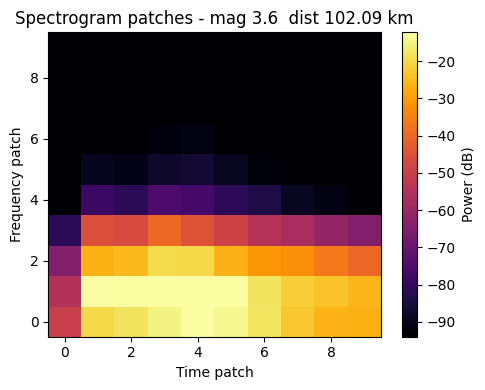

In [2]:
X_spec = np.load('../../data/spectrograms/spectrograms_10x10.npy')

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(X_spec[idx], origin='lower', aspect='auto', cmap='inferno', vmin=VMIN, vmax=VMAX)
fig.colorbar(im, ax=ax, label='Power (dB)')
ax.set_xlabel('Time patch')
ax.set_ylabel('Frequency patch')
ax.set_title(f"Spectrogram patches - mag {row.get('source_magnitude', '?')}  dist {row.get('source_distance_km', '?')} km")
plt.tight_layout()
plt.show()

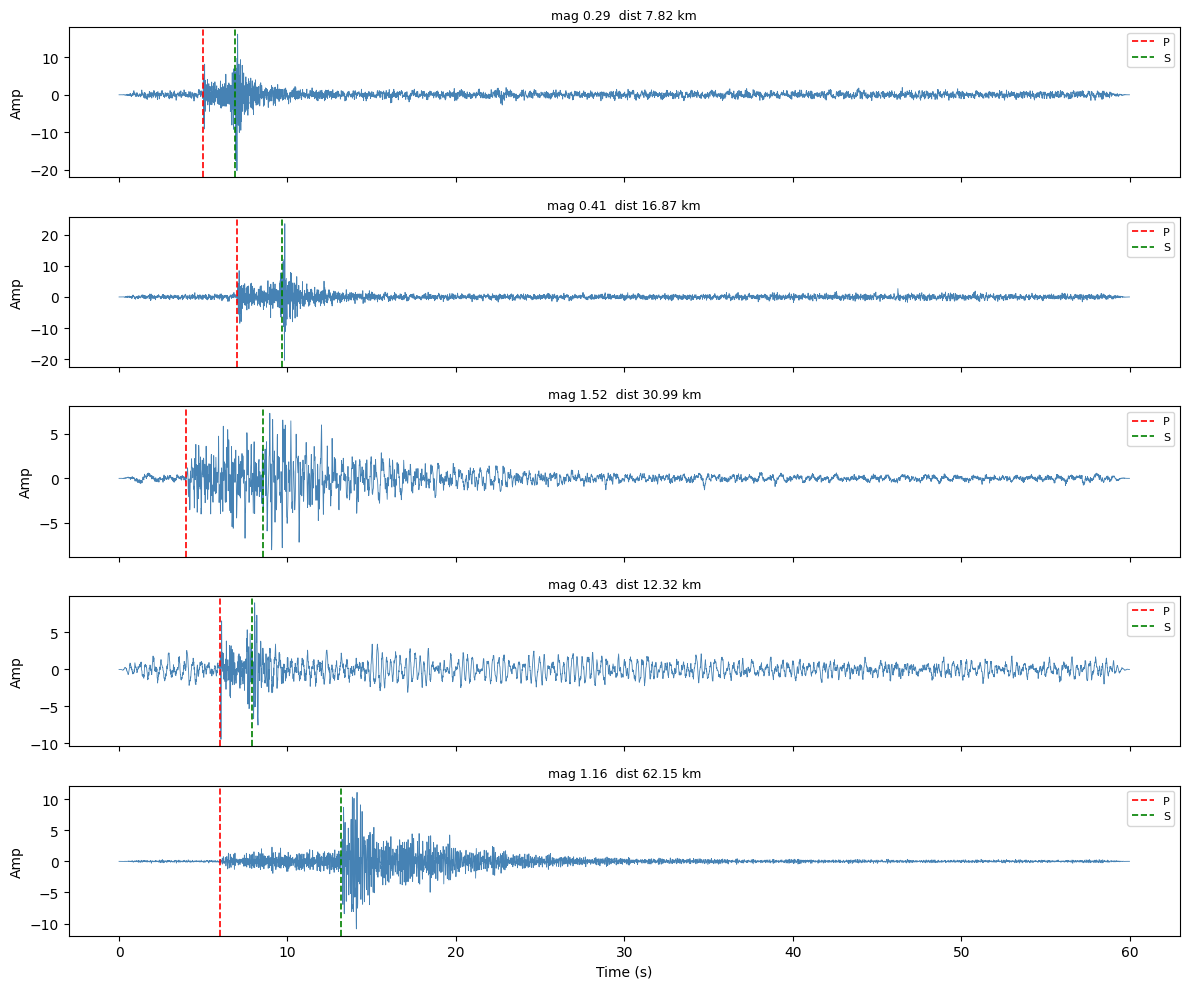

In [3]:
rng     = np.random.default_rng(0)
eq_idxs = np.where(meta['label'].values == 1)[0]
sample  = rng.choice(eq_idxs, size=5, replace=False)

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, i in zip(axes, sample):
    w   = X[i]
    row = meta.iloc[i]
    t   = np.arange(len(w)) / 100.0
    ax.plot(t, w, lw=0.6, color='steelblue')
    for col, label, color in [('p_arrival_sample', 'P', 'red'), ('s_arrival_sample', 'S', 'green')]:
        if col in row and pd.notna(row[col]):
            ax.axvline(row[col] / 100.0, color=color, lw=1.2, linestyle='--', label=label)
    ax.set_title(f"mag {row.get('source_magnitude', '?')}  dist {row.get('source_distance_km', '?')} km", fontsize=9)
    ax.set_ylabel('Amp')
    ax.legend(fontsize=8)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

C:\Users\tomer\AppData\Local\Temp\ipykernel_26364\86408370.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


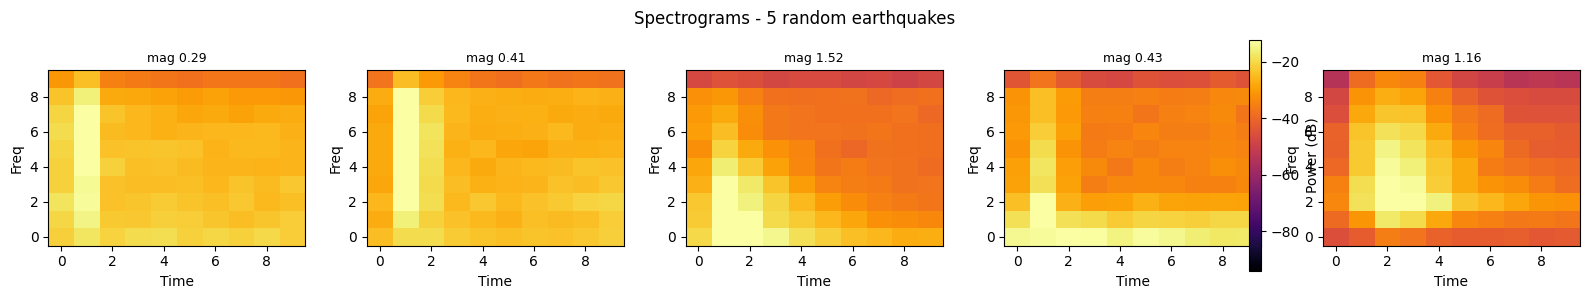

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, i in zip(axes, sample):
    im  = ax.imshow(X_spec[i], origin='lower', aspect='auto', cmap='inferno', vmin=VMIN, vmax=VMAX)
    row = meta.iloc[i]
    ax.set_title(f"mag {row.get('source_magnitude', '?')}", fontsize=9)
    ax.set_xlabel('Time')
    ax.set_ylabel('Freq')
fig.colorbar(im, ax=axes.tolist(), label='Power (dB)')
plt.suptitle('Spectrograms - 5 random earthquakes')
plt.tight_layout()
plt.show()

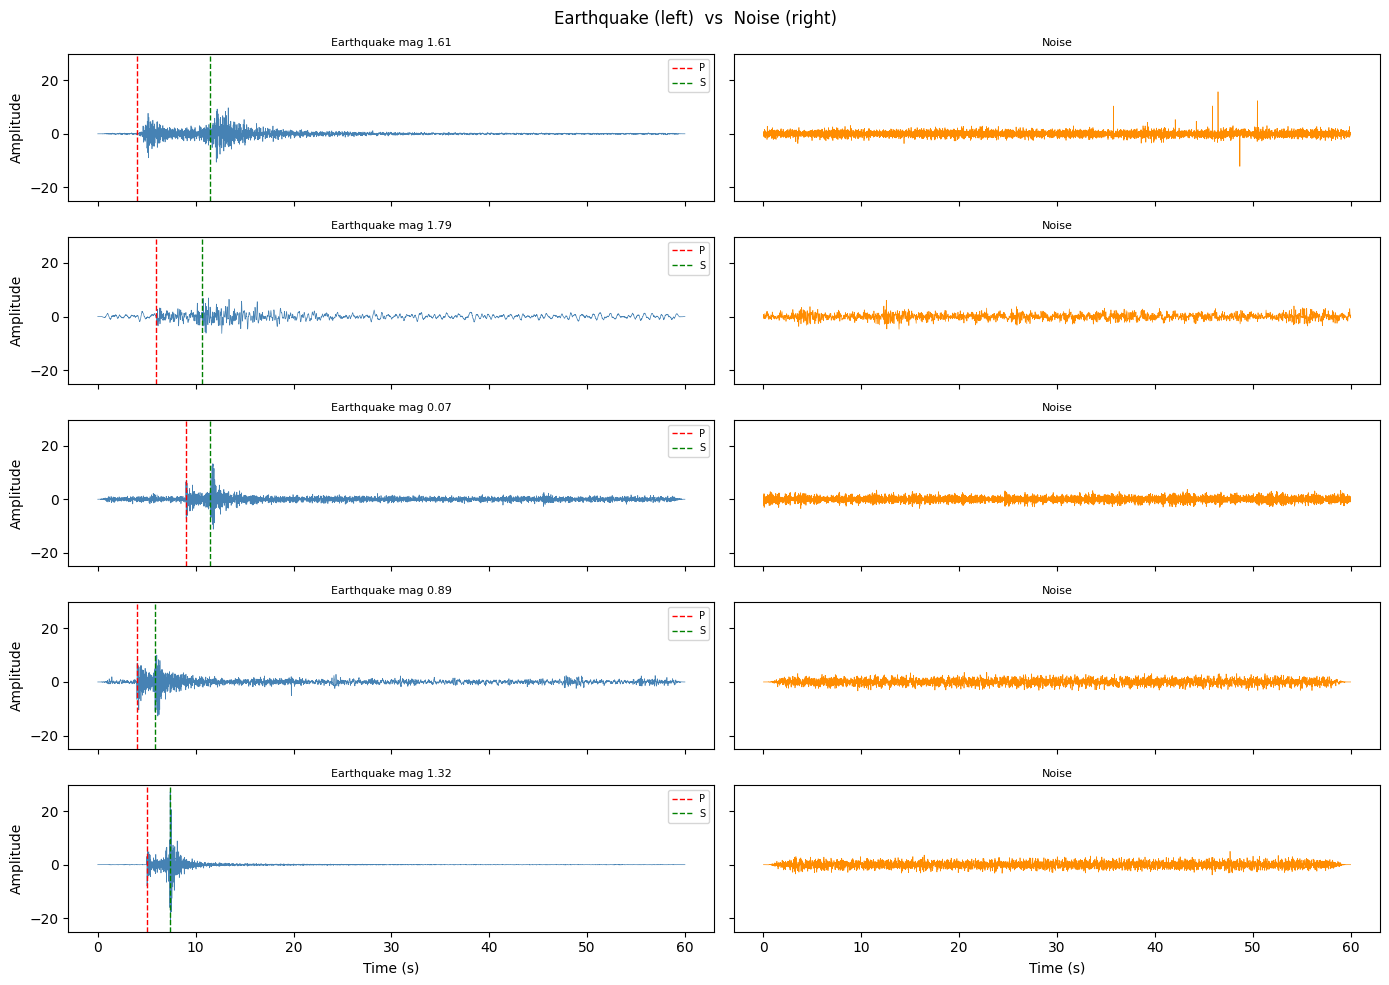

In [5]:
rng        = np.random.default_rng(1)
eq_idxs    = np.where(meta['label'].values == 1)[0]
noise_idxs = np.where(meta['label'].values == 0)[0]
eq_sample    = rng.choice(eq_idxs,    size=5, replace=False)
noise_sample = rng.choice(noise_idxs, size=5, replace=False)

fig, axes = plt.subplots(5, 2, figsize=(14, 10), sharex=True, sharey=True)
fig.suptitle('Earthquake (left)  vs  Noise (right)', fontsize=12)
for row_i, (eq_i, noi_i) in enumerate(zip(eq_sample, noise_sample)):
    for col_i, (trace_idx, color, label) in enumerate([(eq_i, 'steelblue', 'Earthquake'), (noi_i, 'darkorange', 'Noise')]):
        ax  = axes[row_i, col_i]
        row = meta.iloc[trace_idx]
        w   = X[trace_idx]
        t   = np.arange(len(w)) / 100.0
        ax.plot(t, w, lw=0.5, color=color)
        if col_i == 0:
            for col_name, arr_label, arr_color in [('p_arrival_sample', 'P', 'red'), ('s_arrival_sample', 'S', 'green')]:
                if col_name in row and pd.notna(row[col_name]):
                    ax.axvline(row[col_name] / 100.0, color=arr_color, lw=1, linestyle='--', label=arr_label)
            ax.legend(fontsize=7)
        mag = row.get('source_magnitude', '')
        title = label if not (pd.notna(mag) and mag != '') else f"{label} mag {mag}"
        ax.set_title(title, fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('Time (s)')
for ax in axes[:, 0]:
    ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

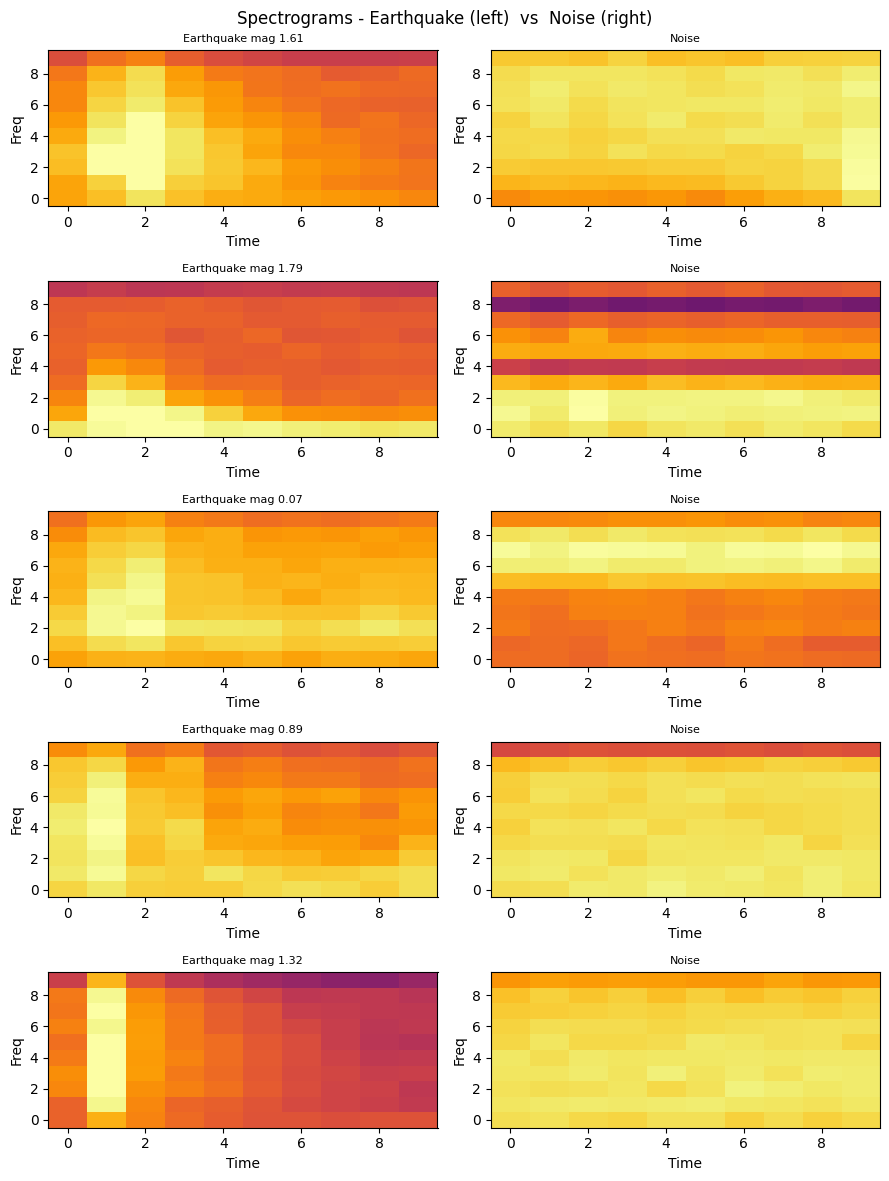

In [6]:
all_idxs = np.concatenate([eq_sample, noise_sample])

fig, axes = plt.subplots(5, 2, figsize=(9, 12))
fig.suptitle('Spectrograms - Earthquake (left)  vs  Noise (right)', fontsize=12)
for row_i, (eq_i, noi_i) in enumerate(zip(eq_sample, noise_sample)):
    for col_i, (trace_idx, label) in enumerate([(eq_i, 'Earthquake'), (noi_i, 'Noise')]):
        ax  = axes[row_i, col_i]
        row = meta.iloc[trace_idx]
        im  = ax.imshow(X_spec[trace_idx], origin='lower', aspect='auto', cmap='inferno', vmin=VMIN, vmax=VMAX)
        mag = row.get('source_magnitude', '')
        ax.set_title(label if not (pd.notna(mag) and mag != '') else f"{label} mag {mag}", fontsize=8)
        ax.set_xlabel('Time')
        ax.set_ylabel('Freq')
plt.tight_layout()
plt.show()

Plotting: B086.PB_20151019125815_EV


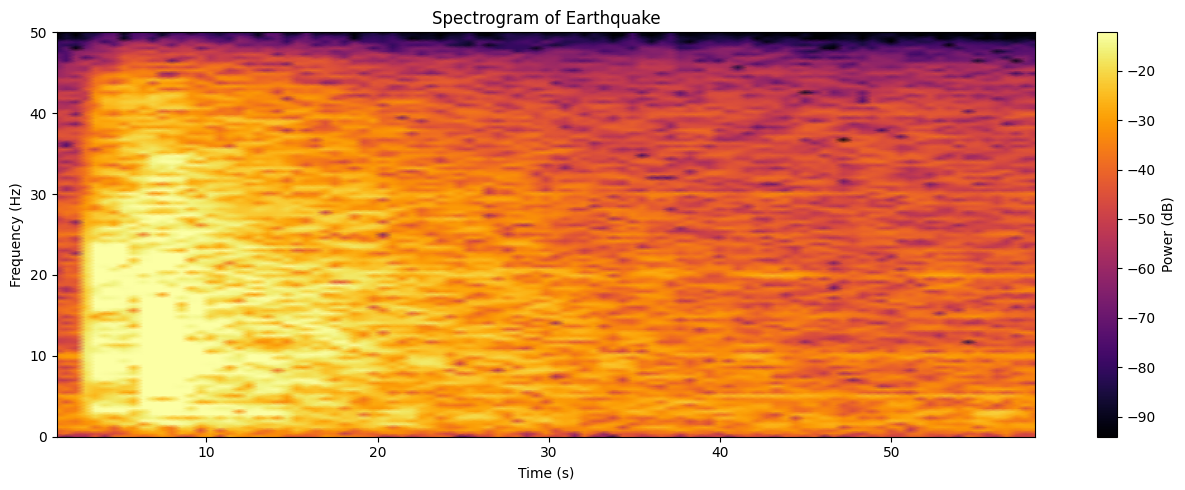

<Axes: title={'center': 'Spectrogram of Earthquake'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>

In [7]:
# Demo: plot_spectrogram — full-resolution spectrogram with global colour scale
from src.data.plot import plot_spectrogram

rng      = np.random.default_rng(7)
eq_idxs  = np.where(meta['label'].values == 1)[0]
trace_id = meta.iloc[rng.choice(eq_idxs)]['trace_name']
print(f'Plotting: {trace_id}')

plot_spectrogram(trace_id, data_dir='../../data')

Noise trace: SCOT.BK_201807201959_NO


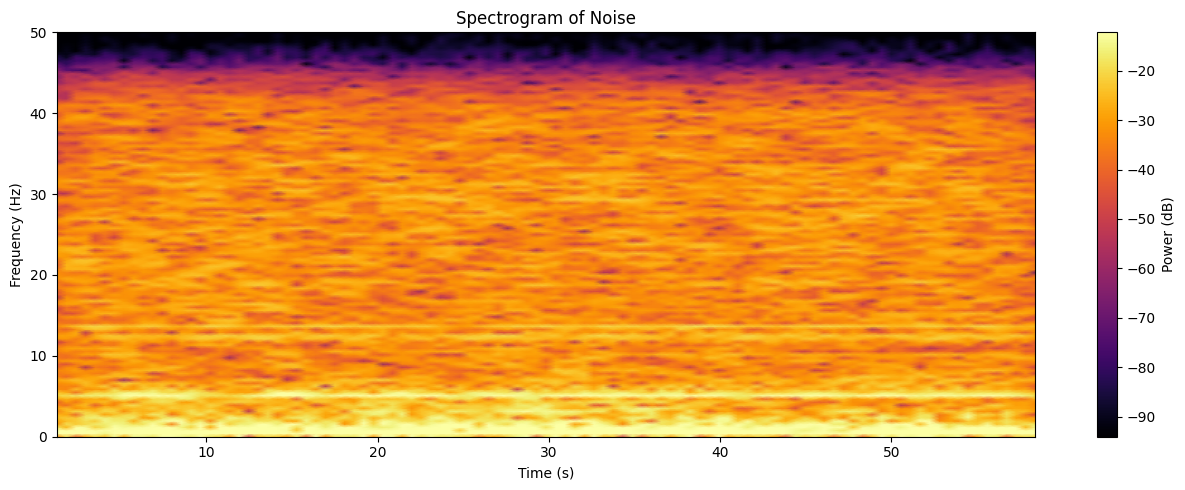

<Axes: title={'center': 'Spectrogram of Noise'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>

In [8]:
# Noise trace for comparison — same colour scale makes the amplitude difference visible
rng        = np.random.default_rng(99)
noise_idxs = np.where(meta['label'].values == 0)[0]
noise_id   = meta.iloc[rng.choice(noise_idxs)]['trace_name']
print(f'Noise trace: {noise_id}')
plot_spectrogram(noise_id, data_dir='../../data')

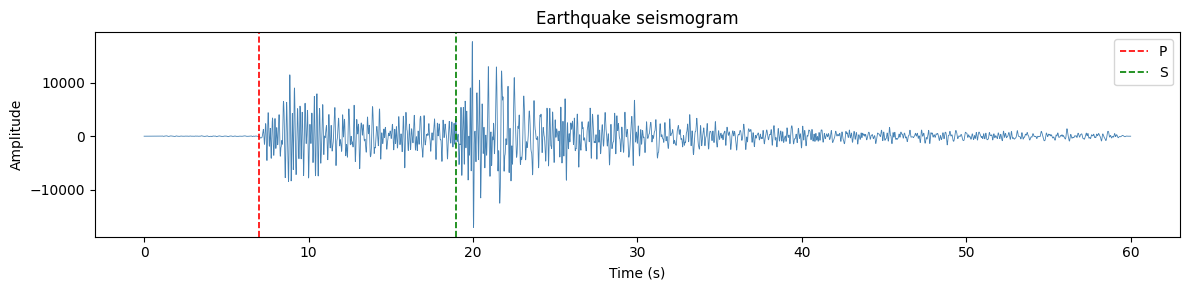

In [9]:
# Single earthquake seismogram — raw counts (not z-scored), straight from the STEAD HDF5
import h5py

eq_idx    = np.where(meta['label'].values == 1)[0][0]
row       = meta.iloc[eq_idx]
trace_id  = row['trace_name']

raw = None
for chunk in ['../../raw_data/chunk1/chunk1.hdf5', '../../raw_data/chunk2/chunk2.hdf5']:
    with h5py.File(chunk, 'r') as hf:
        root = hf.get('data', hf)
        if trace_id in root:
            raw = root[trace_id][:]
            break

z    = raw[:, 2].astype(np.float32)   # Z channel, raw counts
time = np.arange(len(z)) / 100.0

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(time, z, lw=0.6, color='steelblue')
for col, label, color in [('p_arrival_sample', 'P', 'red'), ('s_arrival_sample', 'S', 'green')]:
    if col in row and pd.notna(row[col]):
        ax.axvline(row[col] / 100.0, color=color, lw=1.2, linestyle='--', label=label)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f"Earthquake seismogram")
ax.legend()
plt.tight_layout()
plt.show()